<a href="https://colab.research.google.com/github/vinitdarji16/MLS-Exercise/blob/main/MLS_Exercise8_pedestrian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
import os

dataset_path = "/content/drive/MyDrive/dataset for MLS"

for file in [
    "train.zip",
    "validation.zip",
    "test.zip",
    "test-fog.zip",
    "test-night.zip",
    "test-town-01.zip"
]:
    zip_path = os.path.join(dataset_path, file)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
!ls /content/dataset

test  test-fog	test-night  test-town-01  train  validation


In [5]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

GPU Available: True
GPU: Tesla T4


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from PIL import Image
import os

In [7]:
train_labels = pd.read_csv("/content/dataset/train/labels.csv")
val_labels = pd.read_csv("/content/dataset/validation/labels.csv")
test_labels = pd.read_csv("/content/dataset/test/labels.csv")

print("Training images:", len(train_labels))
print("Validation images:", len(val_labels))
print("Test images:", len(test_labels))

Training images: 7200
Validation images: 3600
Test images: 3600


In [8]:
print(train_labels.head())
print("\nColumns:")
print(train_labels.columns)

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  

Columns:
Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


In [9]:
labels = ["has_traffic_light", "has_pedestrian", "has_vehicle"]

for label in labels:
    print(f"\n{label}")
    print(train_labels[label].value_counts())


has_traffic_light
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64

has_pedestrian
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

has_vehicle
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


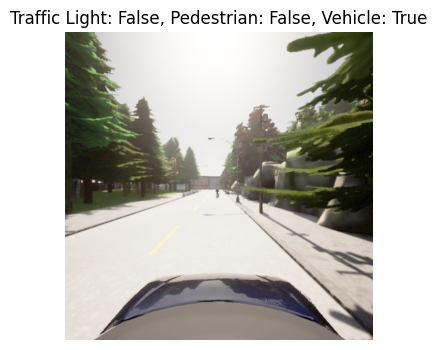

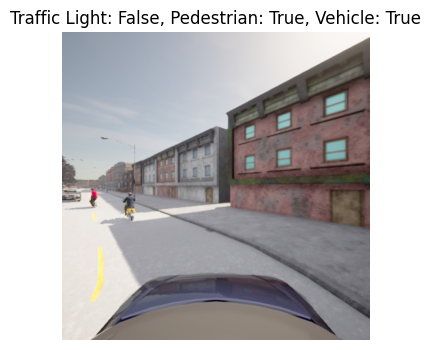

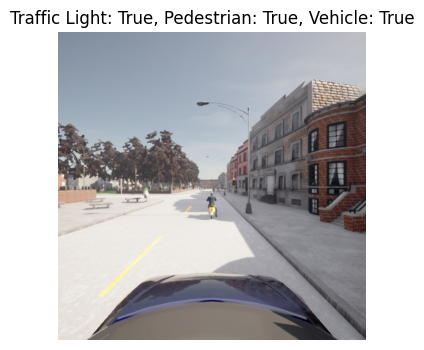

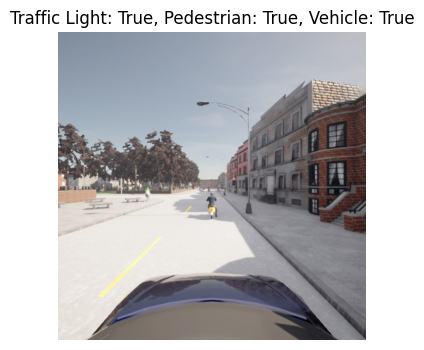

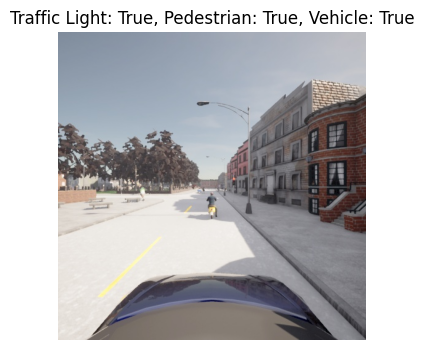

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

image_folder = "/content/dataset/train/rgb-front"

for i in range(5):

    frame = train_labels.iloc[i]["frame"]

    image_name = f"{frame:06d}.jpg"
    image_path = os.path.join(image_folder, image_name)

    img = Image.open(image_path)

    plt.figure(figsize=(6,4))
    plt.imshow(img)

    plt.title(
        f"Traffic Light: {train_labels.iloc[i]['has_traffic_light']}, "
        f"Pedestrian: {train_labels.iloc[i]['has_pedestrian']}, "
        f"Vehicle: {train_labels.iloc[i]['has_vehicle']}"
    )

    plt.axis("off")
    plt.show()

In [11]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [12]:
class CarlaDataset(Dataset):
    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_folder = image_folder
        self.labels_df = labels_df
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        frame = self.labels_df.iloc[idx]["frame"]

        image_name = f"{frame:06d}.jpg"
        image_path = os.path.join(self.image_folder, image_name)

        image = Image.open(image_path).convert("RGB")

        label = int(self.labels_df.iloc[idx][self.target_column])

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset class created successfully!")

Dataset class created successfully!


In [13]:
train_image_folder = "/content/dataset/train/rgb-front"
val_image_folder = "/content/dataset/validation/rgb-front"

pedestrian_train_dataset = CarlaDataset(
    train_image_folder,
    train_labels,
    "has_pedestrian",
    transform
)

pedestrian_val_dataset = CarlaDataset(
    val_image_folder,
    val_labels,
    "has_pedestrian",
    transform
)

print("Pedestrian datasets created!")
print("Training samples:", len(pedestrian_train_dataset))
print("Validation samples:", len(pedestrian_val_dataset))

Pedestrian datasets created!
Training samples: 7200
Validation samples: 3600


In [14]:
train_loader = DataLoader(
    pedestrian_train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    pedestrian_val_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [16]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

model = model.to("cuda")

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer created successfully!")

Loss and optimizer created successfully!


In [22]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [23]:
num_epochs = 10

model = model.to(device)

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # TRAINING
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

print("Training completed!")

Epoch [1/10] | Train Loss: 0.5261 | Val Loss: 0.5756
Epoch [2/10] | Train Loss: 0.4482 | Val Loss: 0.7926
Epoch [3/10] | Train Loss: 0.3962 | Val Loss: 0.6011
Epoch [4/10] | Train Loss: 0.3373 | Val Loss: 0.5649
Epoch [5/10] | Train Loss: 0.2946 | Val Loss: 0.6354
Epoch [6/10] | Train Loss: 0.2448 | Val Loss: 0.7058
Epoch [7/10] | Train Loss: 0.2152 | Val Loss: 0.8336
Epoch [8/10] | Train Loss: 0.1898 | Val Loss: 0.7142
Epoch [9/10] | Train Loss: 0.1621 | Val Loss: 0.9806
Epoch [10/10] | Train Loss: 0.1295 | Val Loss: 1.3119
Training completed!


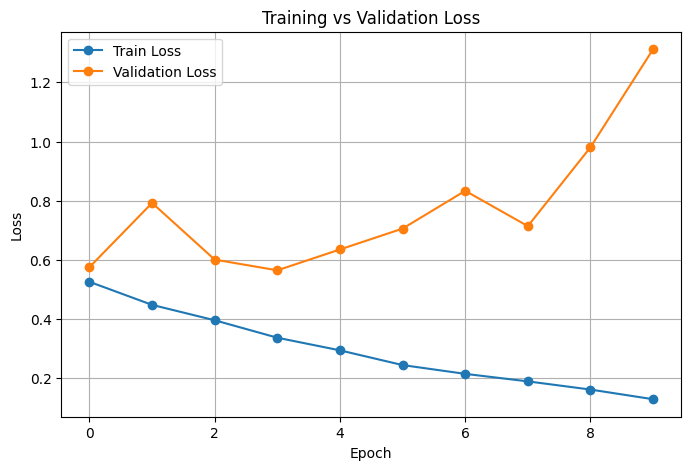

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.grid(True)
plt.show()

In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).squeeze().long()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 75.36%


In [26]:
print(train_labels["has_pedestrian"].value_counts())
print()
print(val_labels["has_pedestrian"].value_counts())

has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

has_pedestrian
False    2686
True      914
Name: count, dtype: int64


Accuracy : 0.8177777777777778
Precision : 0.5796178343949044
Recall : 0.2577903682719547
F1 Score : 0.3568627450980392


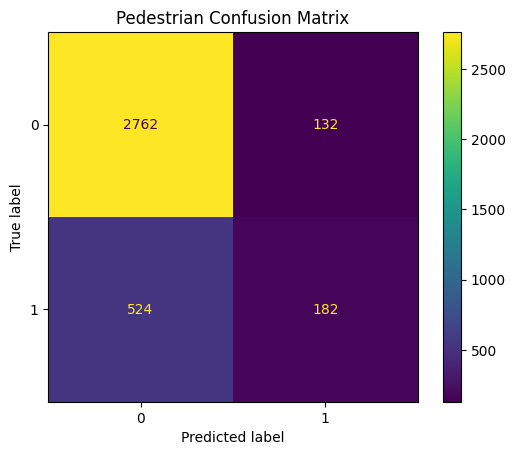

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_image_folder = "/content/dataset/test/rgb-front"

pedestrian_test_dataset = CarlaDataset(
    test_image_folder,
    test_labels,
    "has_pedestrian",
    transform
)

test_loader = DataLoader(
    pedestrian_test_dataset,
    batch_size=32,
    shuffle=False
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).squeeze().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision :", precision_score(all_labels, all_preds))
print("Recall :", recall_score(all_labels, all_preds))
print("F1 Score :", f1_score(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Pedestrian Confusion Matrix")
plt.show()

In [28]:
import torch
from sklearn.metrics import accuracy_score

temperatures = [0.5, 1.0, 2.0]

for T in temperatures:

    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            scaled_outputs = outputs / T

            probs = torch.sigmoid(scaled_outputs)

            preds = (probs > 0.5).squeeze().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)

    print(f"Temperature = {T}")
    print(f"Accuracy = {acc:.4f}")
    print("-"*30)

Temperature = 0.5
Accuracy = 0.8178
------------------------------
Temperature = 1.0
Accuracy = 0.8178
------------------------------
Temperature = 2.0
Accuracy = 0.8178
------------------------------


In [29]:
import torch
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

def fgsm_attack(model, image, label, epsilon):

    image = image.clone().detach().to(device)
    image.requires_grad = True

    label = torch.tensor([[label]], dtype=torch.float).to(device)

    output = model(image)

    loss = criterion(output, label)

    model.zero_grad()
    loss.backward()

    data_grad = image.grad.data

    perturbed_image = image + epsilon * data_grad.sign()

    perturbed_image = torch.clamp(
        perturbed_image,
        image.min(),
        image.max()
    )

    return perturbed_image.detach()

In [30]:
epsilons = [0.01, 0.05, 0.10]

images, labels = next(iter(test_loader))

sample_image = images[0].unsqueeze(0).to(device)
sample_label = labels[0].item()

adv_examples = []

for eps in epsilons:

    adv = fgsm_attack(
        model,
        sample_image,
        sample_label,
        eps
    )

    adv_examples.append(adv.cpu())

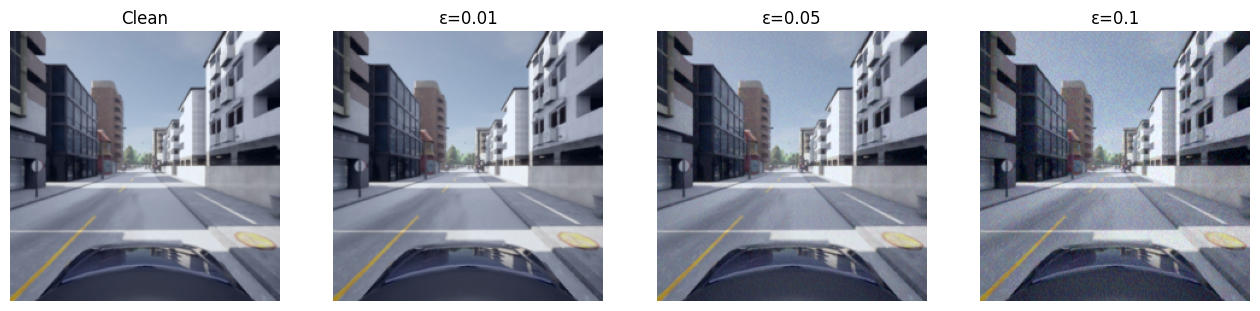

In [31]:
import matplotlib.pyplot as plt

clean = sample_image.squeeze().cpu().permute(1,2,0).numpy()
clean = (clean-clean.min())/(clean.max()-clean.min())

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(clean)
plt.title("Clean")
plt.axis("off")

for i,eps in enumerate(epsilons):

    adv = adv_examples[i].squeeze().permute(1,2,0).numpy()
    adv = (adv-adv.min())/(adv.max()-adv.min())

    plt.subplot(1,4,i+2)
    plt.imshow(adv)
    plt.title(f"ε={eps}")
    plt.axis("off")

plt.show()

In [32]:
from sklearn.metrics import recall_score

eps_list = [0.01, 0.05, 0.10]

recalls = []

for eps in eps_list:

    y_true = []
    y_pred = []

    for images, labels in test_loader:

        adv_batch = []

        for i in range(images.size(0)):

            adv = fgsm_attack(
                model,
                images[i].unsqueeze(0),
                labels[i].item(),
                eps
            )

            adv_batch.append(adv)

        adv_batch = torch.cat(adv_batch, dim=0)

        with torch.no_grad():

            outputs = model(adv_batch)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).int().cpu().numpy().flatten()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

    recall = recall_score(y_true, y_pred)

    recalls.append(recall)

    print(f"Epsilon = {eps:.2f} Recall = {recall:.4f}")

Epsilon = 0.01 Recall = 0.0822
Epsilon = 0.05 Recall = 0.0142
Epsilon = 0.10 Recall = 0.0354


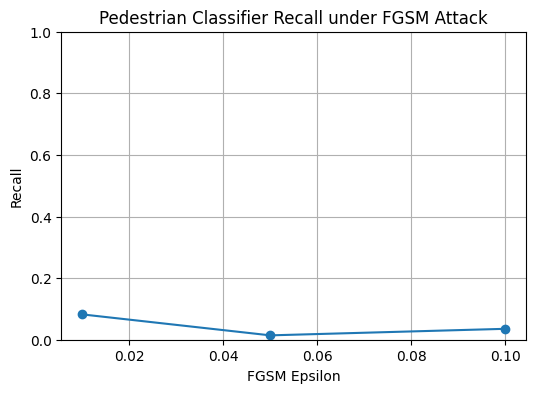

In [33]:
plt.figure(figsize=(6,4))

plt.plot(
    eps_list,
    recalls,
    marker="o"
)

plt.xlabel("FGSM Epsilon")
plt.ylabel("Recall")
plt.title("Pedestrian Classifier Recall under FGSM Attack")

plt.grid(True)

plt.ylim(0,1)

plt.show()